In [5]:
import joblib
import glob
import os
from pathlib import Path
from typing import Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# =====================================================================
# CONFIGURASI DIREKTORI, TIMESTAMP & FILE EVALUASI
# =====================================================================
waktu_sekarang = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Timestamp evaluasi saat ini: {waktu_sekarang}")

LABEL_COL = "label"

# Rute Direktori Dinamis yang tersinkronisasi dengan ekstraktor
INPUT_DIR = Path("hasil_ekstraksi")
MODEL_DIR = Path("output/models")
GRAPH_OUT_DIR = Path("output/grafik")
GRAPH_OUT_DIR.mkdir(parents=True, exist_ok=True)
METRIC_OUT_DIR = Path("output/metrik")
METRIC_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Berkas Induk Data Uji Murni (Baseline)
BASELINE_TEST_CSV = "fitur_test_set.csv"

# Mapping 4 Teknik Obfuskasi Data Uji (Sesuai dengan Output Ekstraktor Terbaru)
TEST_FILES = {
    "Data Asli (Baseline)" : "fitur_test_set.csv",
    "ASCII Encoding"       : "fitur_test_set_obf_ASCII_Encoding.csv",
    "String Concatenation" : "fitur_test_set_obf_String_Concatenation.csv",
    "String Reordering"    : "fitur_test_set_obf_String_Reordering.csv",
    "Token Manipulation"   : "fitur_test_set_obf_Token_Manipulation.csv"
}

print("✅ [CELL 0] Pustaka, Direktori Dinamis, dan Mapping Data Uji Berhasil Dimuat.")

Timestamp evaluasi saat ini: 20260809_110044
✅ [CELL 0] Pustaka, Direktori Dinamis, dan Mapping Data Uji Berhasil Dimuat.


In [6]:
def _plot_combined_confusion_matrix(scenario_label: str, models_data: dict, timestamp: str) -> None:
    """Mengonstruksi grid Confusion Matrix untuk seluruh model dalam satu skenario."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    fig.suptitle(f"Confusion Matrix: {scenario_label}", fontsize=18, fontweight='bold', y=0.97)
    
    axes = axes.flatten()
    for idx, (model_name, m_data) in enumerate(models_data.items()):
        cm = m_data['cm']
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False,
                    xticklabels=["Benign", "Malicious"],
                    yticklabels=["Benign", "Malicious"],
                    annot_kws={"size": 14})
        axes[idx].set_title(model_name, fontsize=14, fontweight='bold')
        axes[idx].set_xlabel("Predicted Label", fontsize=12)
        axes[idx].set_ylabel("True Label", fontsize=12)
        
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    
    # Ekspor Grafik Otomatis
    safe_label = scenario_label.replace(' ', '_').replace('(', '').replace(')', '')
    file_path = GRAPH_OUT_DIR / f"cm_{safe_label}_{timestamp}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"      -> Confusion Matrix disimpan di: {file_path.name}")

# =====================================================================
# FUNGSI VISUALISASI KURVA BERORIENTASI LANDSCAPE
# =====================================================================

def _plot_roc_curves_landscape_grid(plot_data_registry: dict, timestamp: str) -> None:
    """Mengonstruksi Kelompok Kurva ROC dalam format Grid Landscape."""
    scenarios = list(plot_data_registry.keys())
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 11))
    axes = axes.flatten()
    
    for idx, scenario_label in enumerate(scenarios):
        ax_roc = axes[idx]
        models_data = plot_data_registry[scenario_label]
        
        for model_name, m_data in models_data.items():
            y_true = m_data['y_true']
            y_proba = m_data['y_proba']
            
            if np.sum(y_true) > 0 and len(np.unique(y_true)) > 1:
                fpr, tpr, _ = roc_curve(y_true, y_proba)
                roc_auc = auc(fpr, tpr)
                ax_roc.plot(fpr, tpr, lw=2.5, label=f"{model_name} (AUC = {roc_auc:.4f})")
        
        ax_roc.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=10)
        ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=10)
        ax_roc.set_title(f'{scenario_label}', fontsize=12, fontweight='bold', pad=8)
        ax_roc.legend(loc="lower right", fontsize=9)
        ax_roc.grid(True, linestyle='--', alpha=0.5)
        
    if len(scenarios) < len(axes):
        for empty_idx in range(len(scenarios), len(axes)):
            fig.delaxes(axes[empty_idx])
            
    fig.suptitle('Kurva Receiver Operating Characteristic (ROC)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    
    file_path = GRAPH_OUT_DIR / f"roc_curve_all_{timestamp}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"▶ [LANDSCAPE] Grup Visualisasi Kurva ROC Berhasil Di-render & Disimpan: {file_path.name}")


def _plot_pr_curves_landscape_grid(plot_data_registry: dict, timestamp: str) -> None:
    """Mengonstruksi Kelompok Kurva Precision-Recall (PR) dalam format Grid Landscape."""
    scenarios = list(plot_data_registry.keys())
    nrows, ncols = 2, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 11))
    axes = axes.flatten()
    
    for idx, scenario_label in enumerate(scenarios):
        ax_pr = axes[idx]
        models_data = plot_data_registry[scenario_label]
        
        for model_name, m_data in models_data.items():
            y_true = m_data['y_true']
            y_proba = m_data['y_proba']
            
            if np.sum(y_true) > 0 and len(np.unique(y_true)) > 1:
                precision, recall, _ = precision_recall_curve(y_true, y_proba)
                pr_auc = average_precision_score(y_true, y_proba)
                ax_pr.plot(recall, precision, lw=2.5, label=f"{model_name} (PR AUC = {pr_auc:.4f})")
        
        first_model_key = list(models_data.keys())[0]
        baseline_ratio = np.sum(models_data[first_model_key]['y_true']) / len(models_data[first_model_key]['y_true'])
        
        ax_pr.plot([0, 1], [baseline_ratio, baseline_ratio], color='black', lw=1.5, linestyle='--', label=f'Baseline ({baseline_ratio:.2f})')
        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_xlabel('Recall', fontsize=10)
        ax_pr.set_ylabel('Precision', fontsize=10)
        ax_pr.set_title(f'{scenario_label}', fontsize=12, fontweight='bold', pad=8)
        ax_pr.legend(loc="lower left", fontsize=9)
        ax_pr.grid(True, linestyle='--', alpha=0.5)
        
    if len(scenarios) < len(axes):
        for empty_idx in range(len(scenarios), len(axes)):
            fig.delaxes(axes[empty_idx])
            
    fig.suptitle('Kurva Precision-Recall (PR)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    
    file_path = GRAPH_OUT_DIR / f"pr_curve_all_{timestamp}.png"
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"▶ [LANDSCAPE] Grup Visualisasi Kurva PR Berhasil Di-render & Disimpan: {file_path.name}")

print("✅ [CELL 1] Skrip Pemformat Visualisasi Auto-Save Berhasil Dimuat.")

✅ [CELL 1] Skrip Pemformat Visualisasi Auto-Save Berhasil Dimuat.


In [7]:
def _print_comparison_table_formatted(result_rows: list, timestamp: str) -> None:
    """Mencetak laporan perbandingan metrik kinerja semua model ke bentuk tabel teks formal."""
    df_results = pd.DataFrame(result_rows)
    print("\n" + "="*145)
    print(f"{'TABEL KOMPARASI EVALUASI METRIK DETEKSI (BASELINE VS AUGMENTASI)':^145}")
    print("="*145)
    
    # Ekspor tabel log ke CSV sebelum diubah jadi string
    out_csv = METRIC_OUT_DIR / f"evaluasi_test_set_{timestamp}.csv"
    df_results.to_csv(out_csv, index=False)
    
    # [DIPERBARUI]: Menambahkan 'FPR' dan 'FNR' agar diformat 4 angka di belakang koma
    float_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'FPR', 'FNR', 'ROC AUC', 'PR AUC']
    for col in float_cols:
        if col in df_results.columns:
            df_results[col] = df_results[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)
            
    print(df_results.to_string(index=False))
    print("="*145)
    print(f"✅ Tabel hasil evaluasi komprehensif berhasil diekspor secara permanen ke: {out_csv.name}\n")

print("✅ [CELL 2] Skrip Pemformat Tabel Metrik dan Ekspor CSV Berhasil Dimuat.")

✅ [CELL 2] Skrip Pemformat Tabel Metrik dan Ekspor CSV Berhasil Dimuat.


▶ MULAI EKSEKUSI PIPELINE EVALUASI: 2026-08-09 11:00:44
[*] Memuat seluruh model .joblib terbaru dari direktori output...
    - Berhasil memuat: RF (Baseline)
    - Berhasil memuat: RF (Augmentasi)
    - Berhasil memuat: XGB (Baseline)
    - Berhasil memuat: XGB (Augmentasi)
    - Berhasil memuat: LGBM (Baseline)
    - Berhasil memuat: LGBM (Augmentasi)
✅ Sukses memuat 6 arsitektur model untuk dievaluasi.

[*] Menjalankan Pengujian Komparatif Lintas Skenario Teknik...

                                        TABEL KOMPARASI EVALUASI METRIK DETEKSI (BASELINE VS AUGMENTASI)                                         
        Skenario Uji    Model-Skenario Accuracy Precision Recall F1-Score    FPR    FNR ROC AUC PR AUC
Data Asli (Baseline)     RF (Baseline)   0.9725    0.9831 0.9257   0.9536 0.0070 0.0743  0.9917 0.9885
Data Asli (Baseline)   RF (Augmentasi)   0.9620    0.9459 0.9284   0.9371 0.0232 0.0716  0.9914 0.9862
Data Asli (Baseline)    XGB (Baseline)   0.9733    0.9859 0.9257   0.95

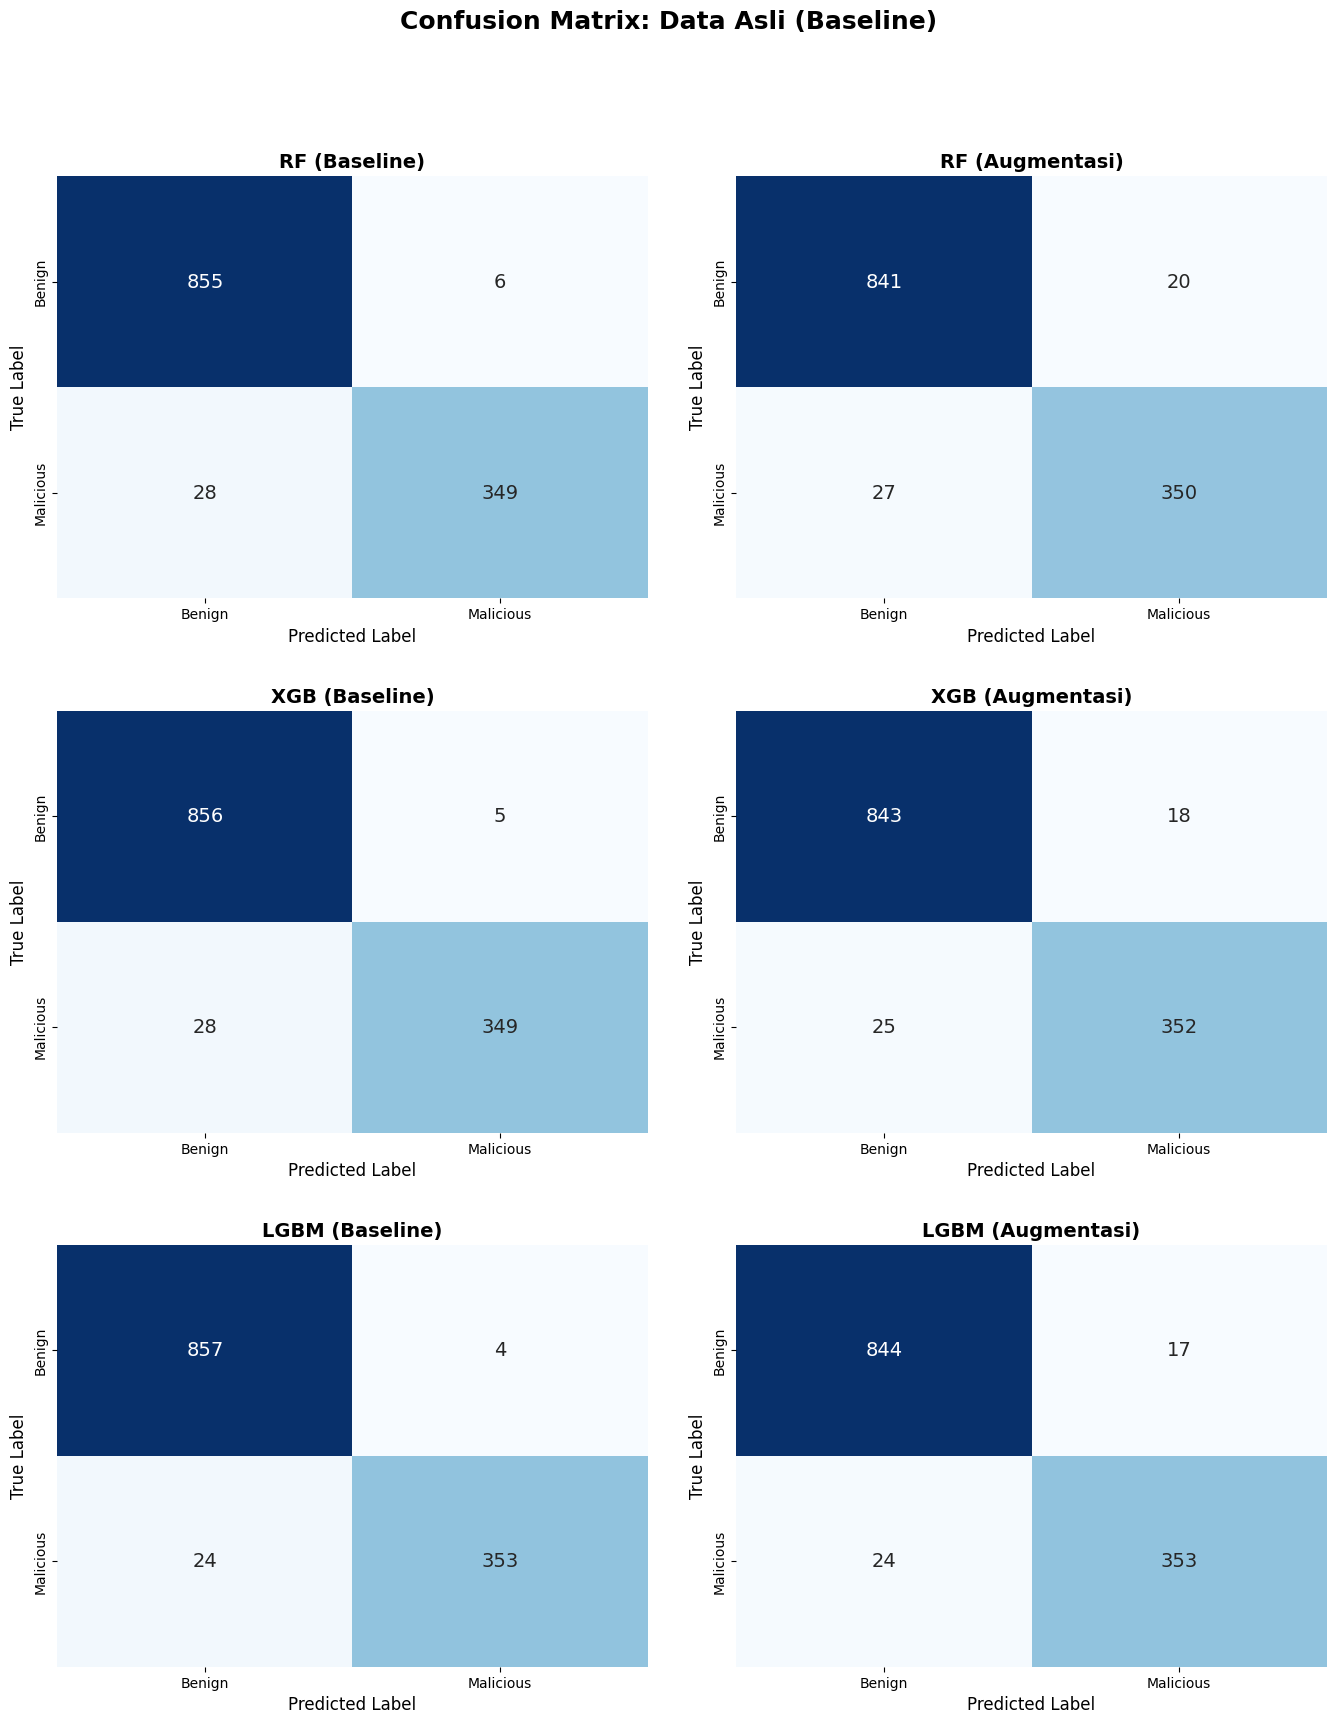

      -> Confusion Matrix disimpan di: cm_Data_Asli_Baseline_20260809_110044.png


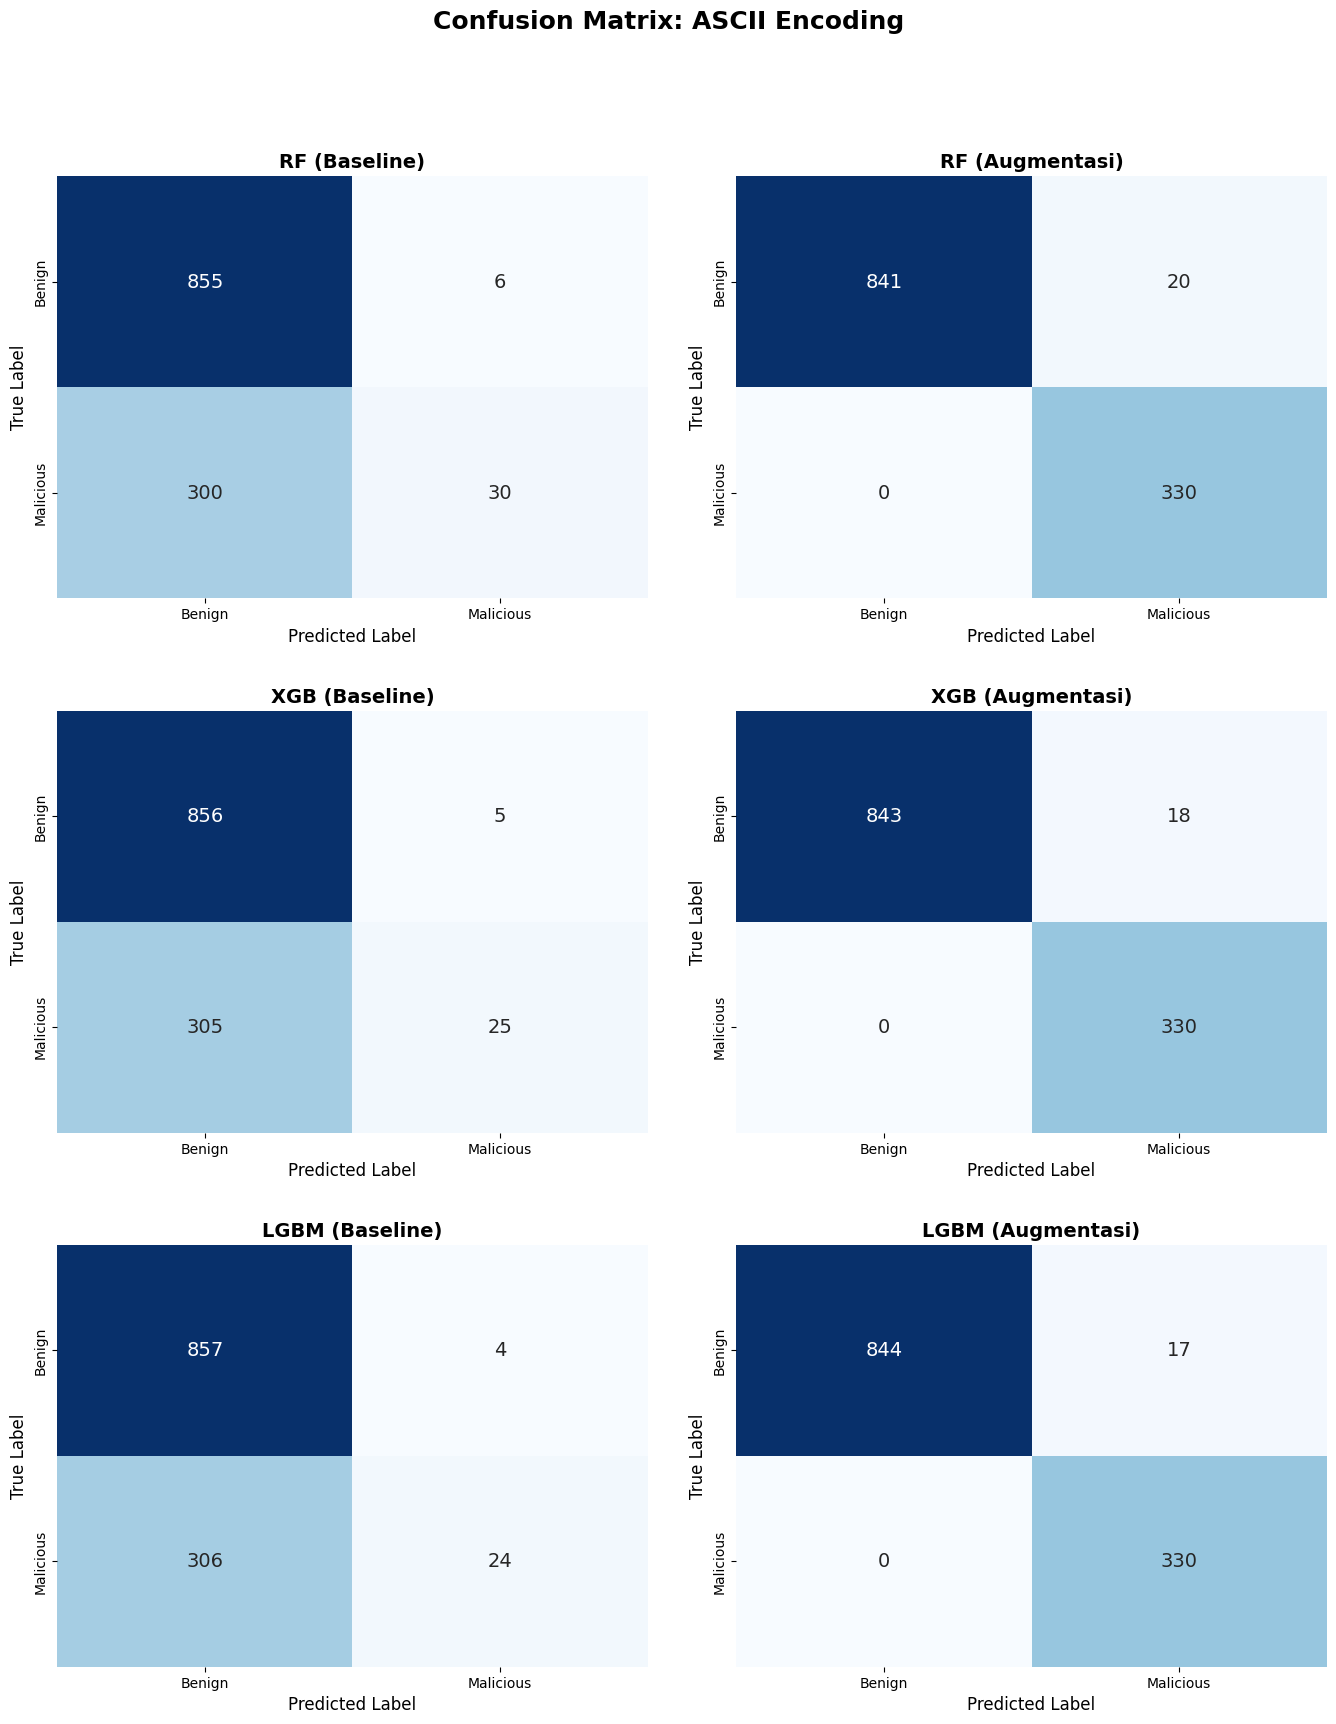

      -> Confusion Matrix disimpan di: cm_ASCII_Encoding_20260809_110044.png


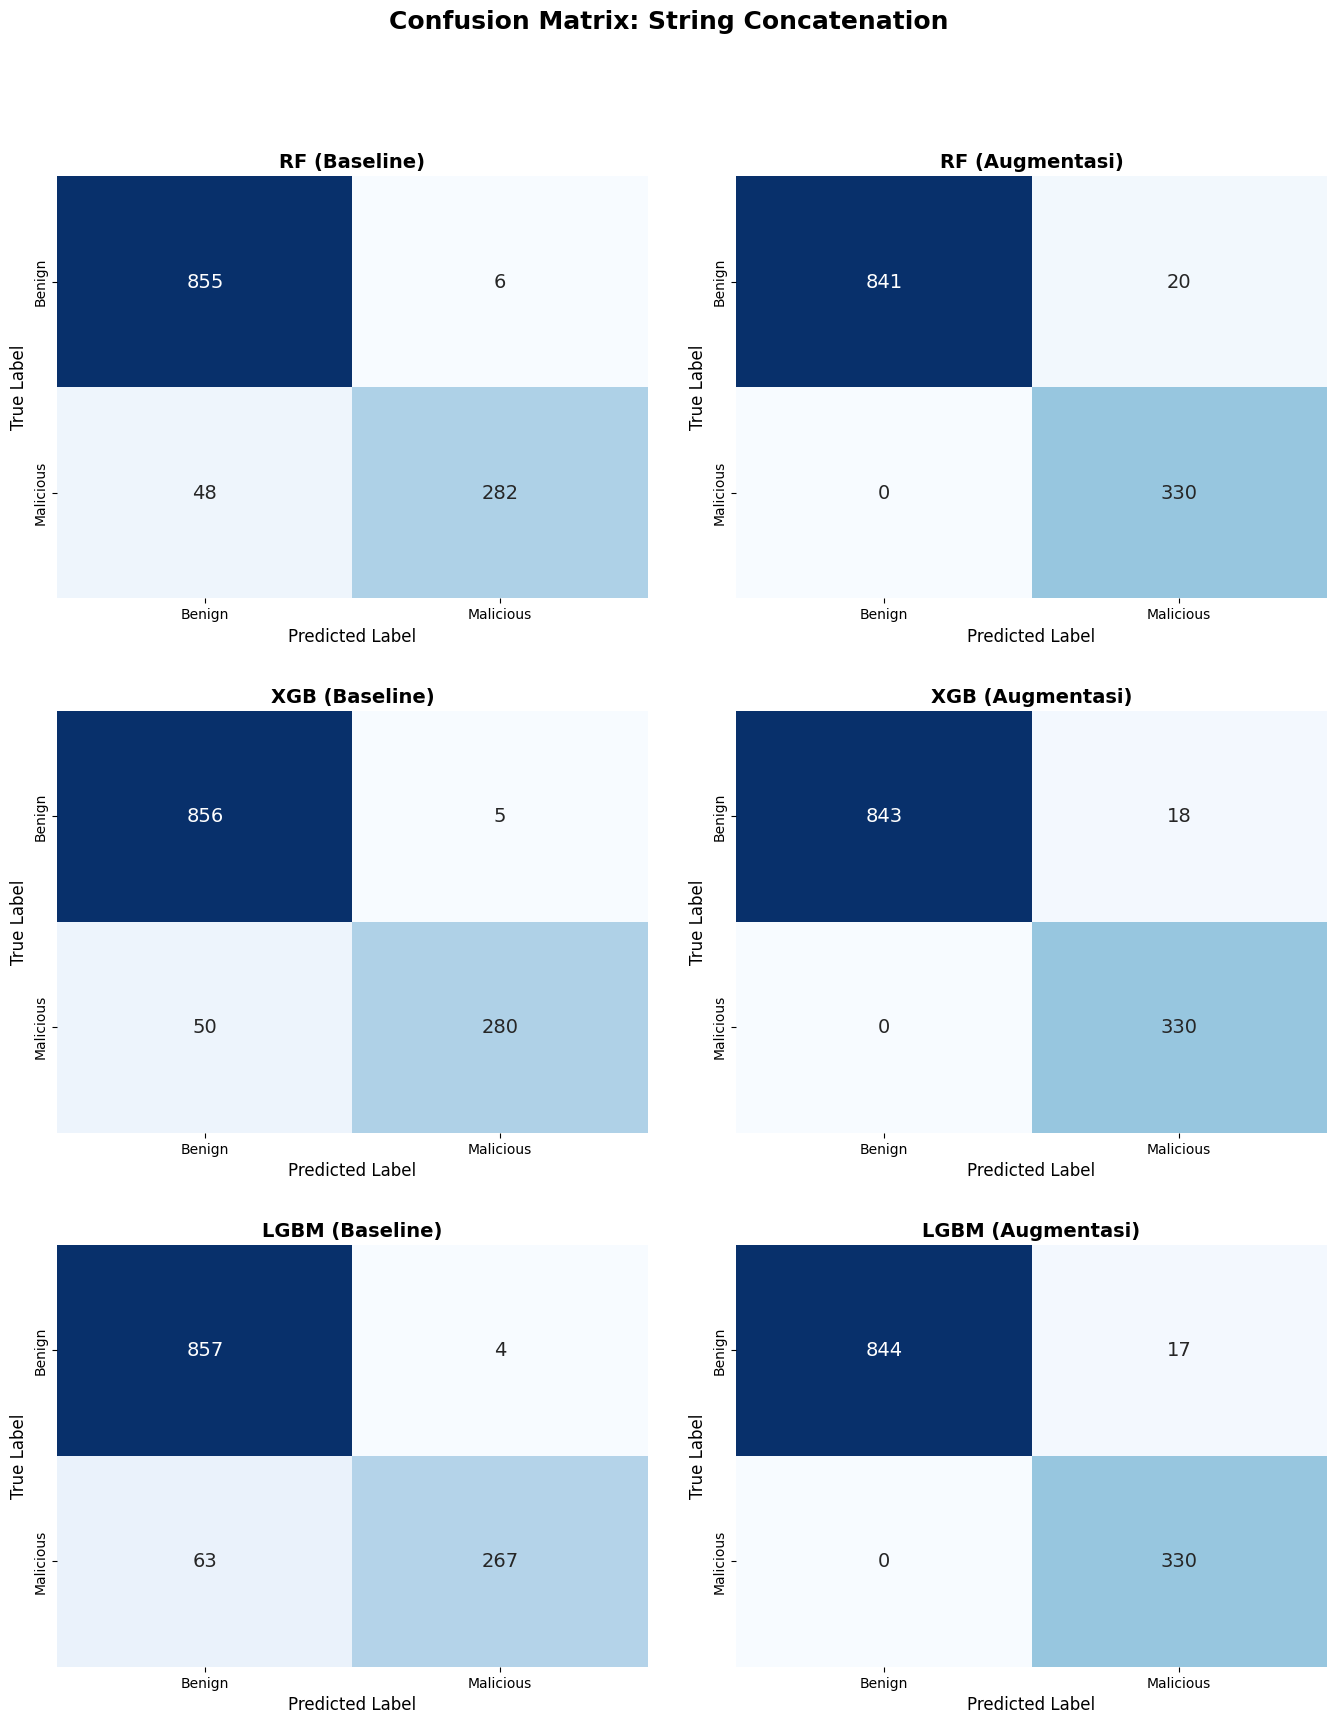

      -> Confusion Matrix disimpan di: cm_String_Concatenation_20260809_110044.png


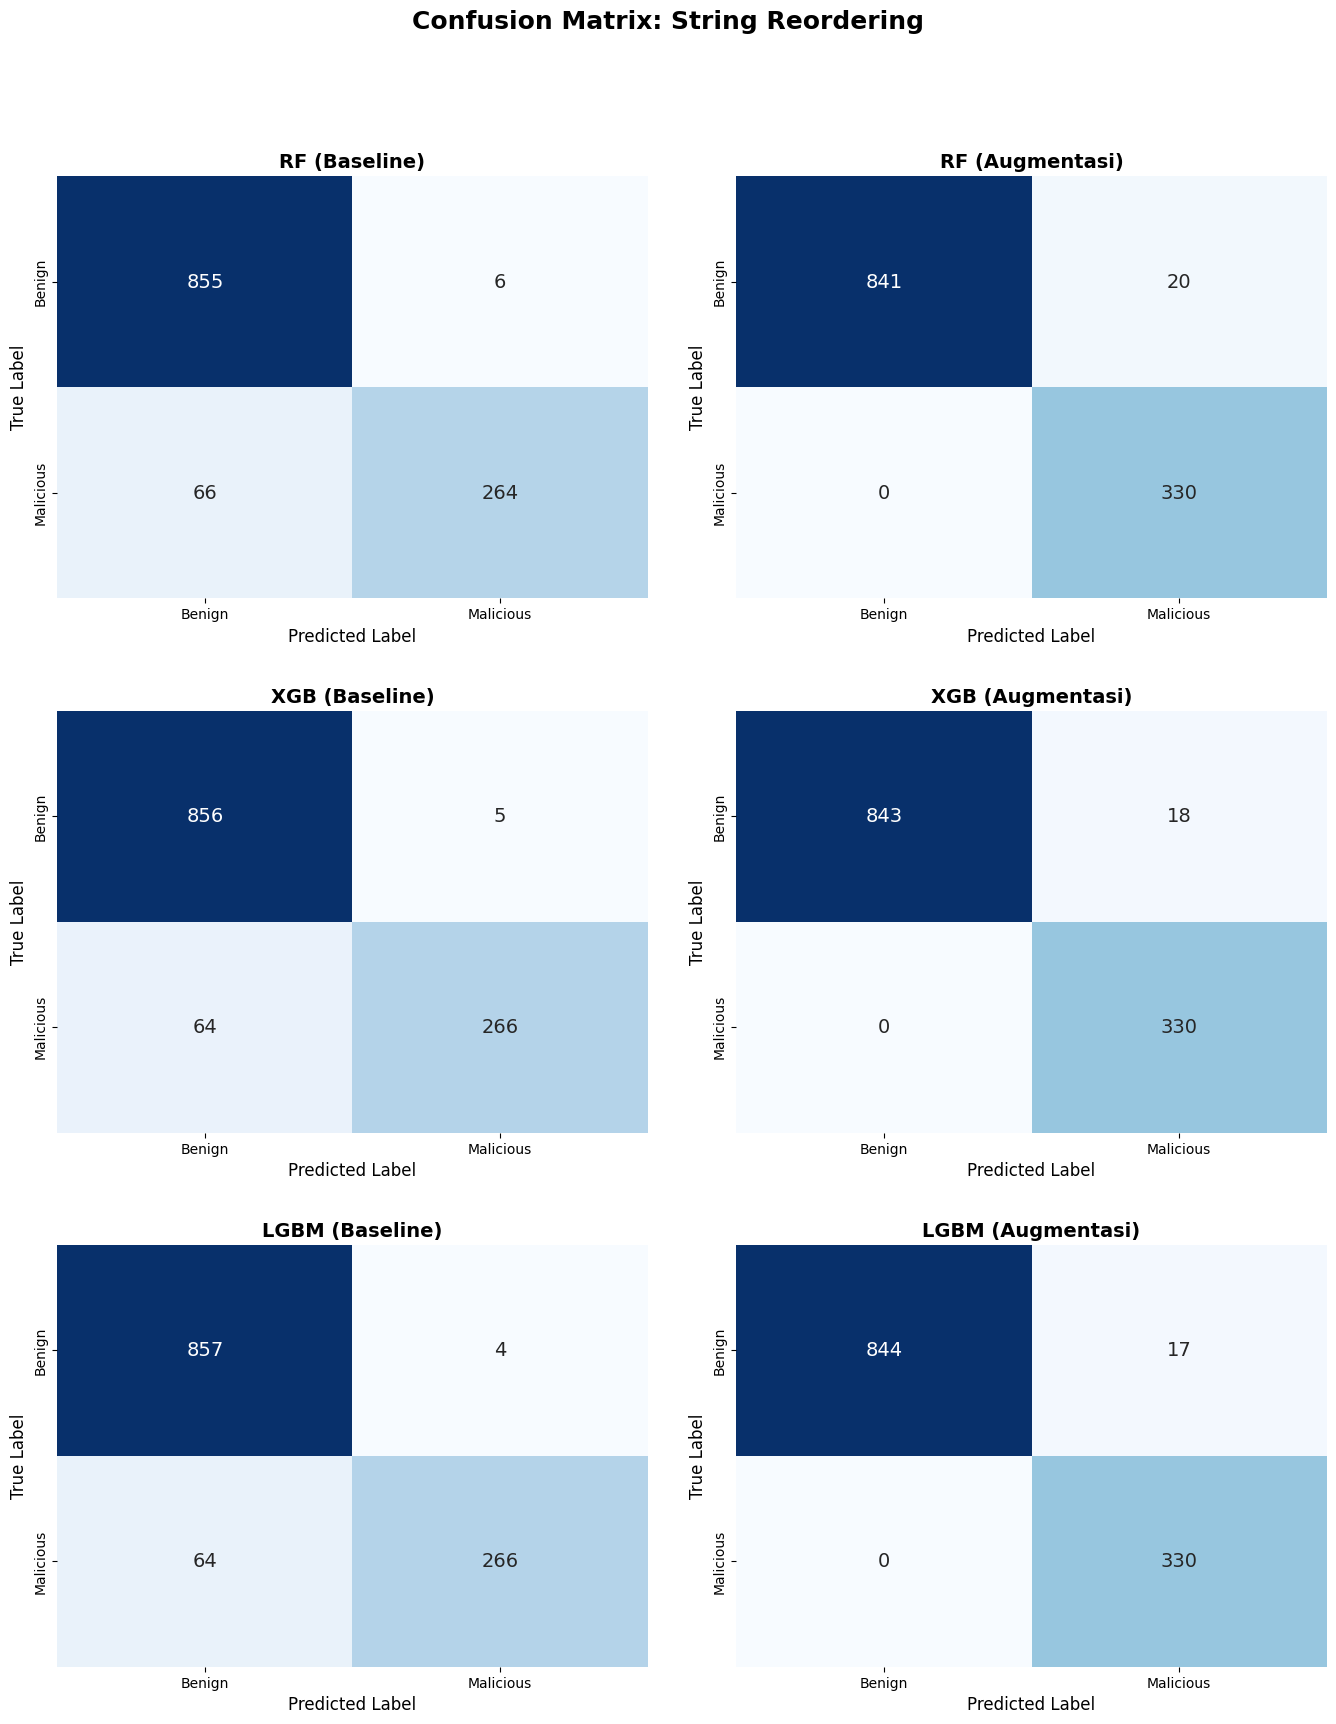

      -> Confusion Matrix disimpan di: cm_String_Reordering_20260809_110044.png


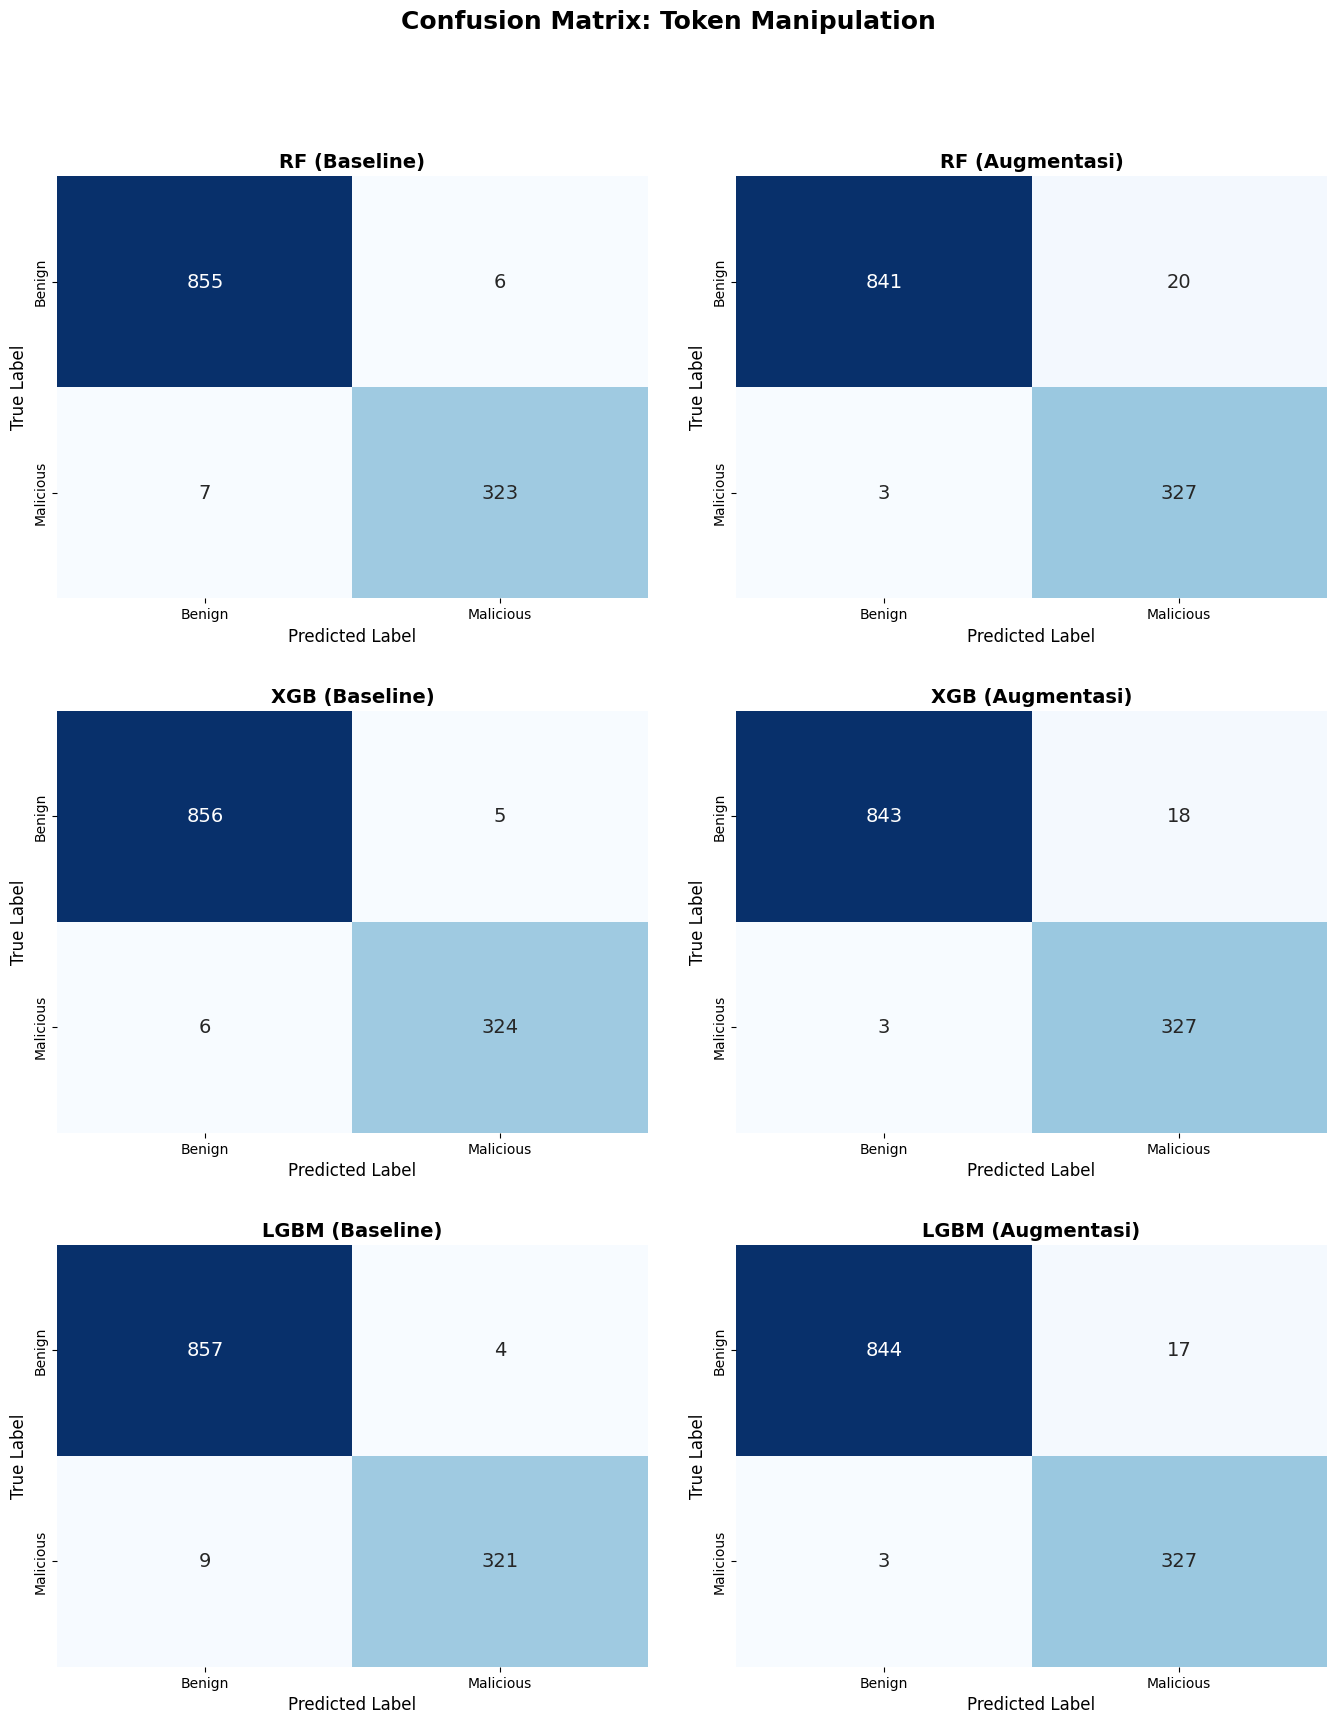

      -> Confusion Matrix disimpan di: cm_Token_Manipulation_20260809_110044.png

=== MENAMPILKAN BLOK VISUAL 1: GRUP KURVA ROC (LANDSCAPE) ===


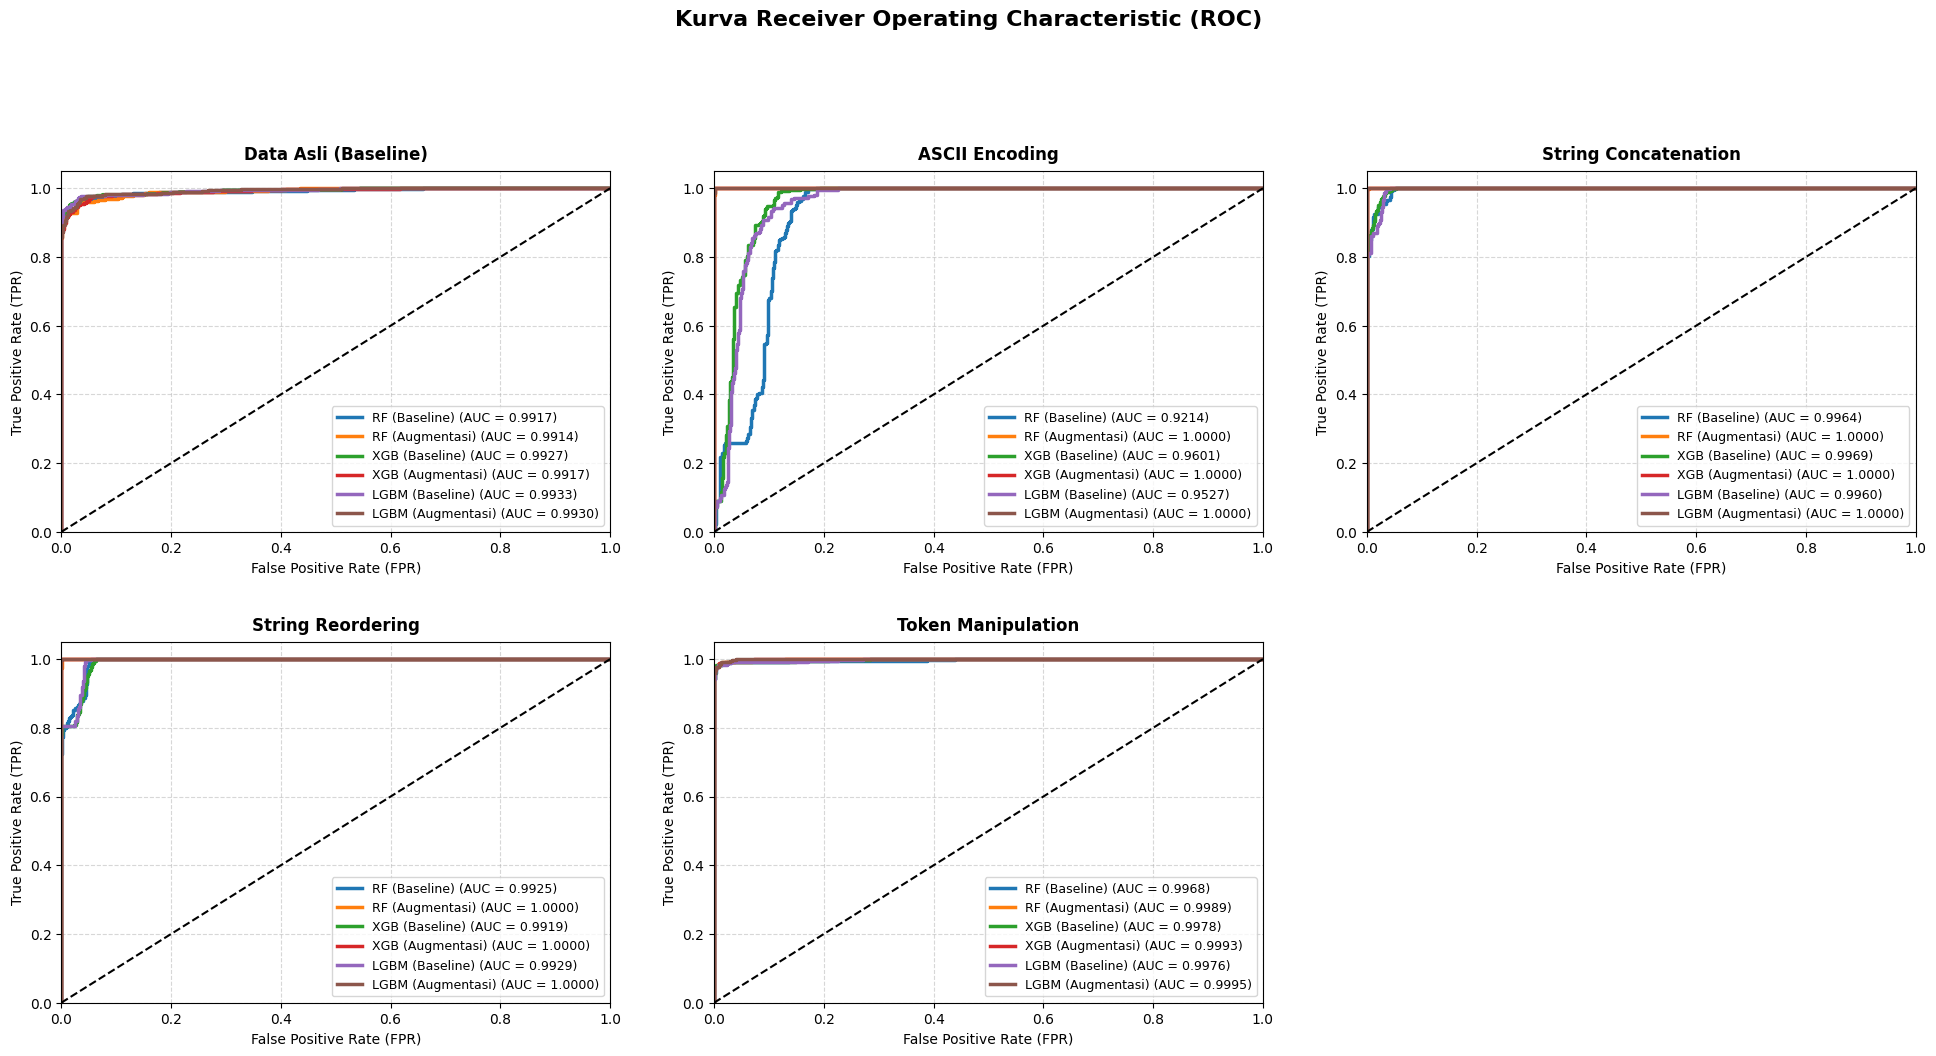

▶ [LANDSCAPE] Grup Visualisasi Kurva ROC Berhasil Di-render & Disimpan: roc_curve_all_20260809_110044.png

=== MENAMPILKAN BLOK VISUAL 2: GRUP KURVA PRECISION-RECALL (LANDSCAPE) ===


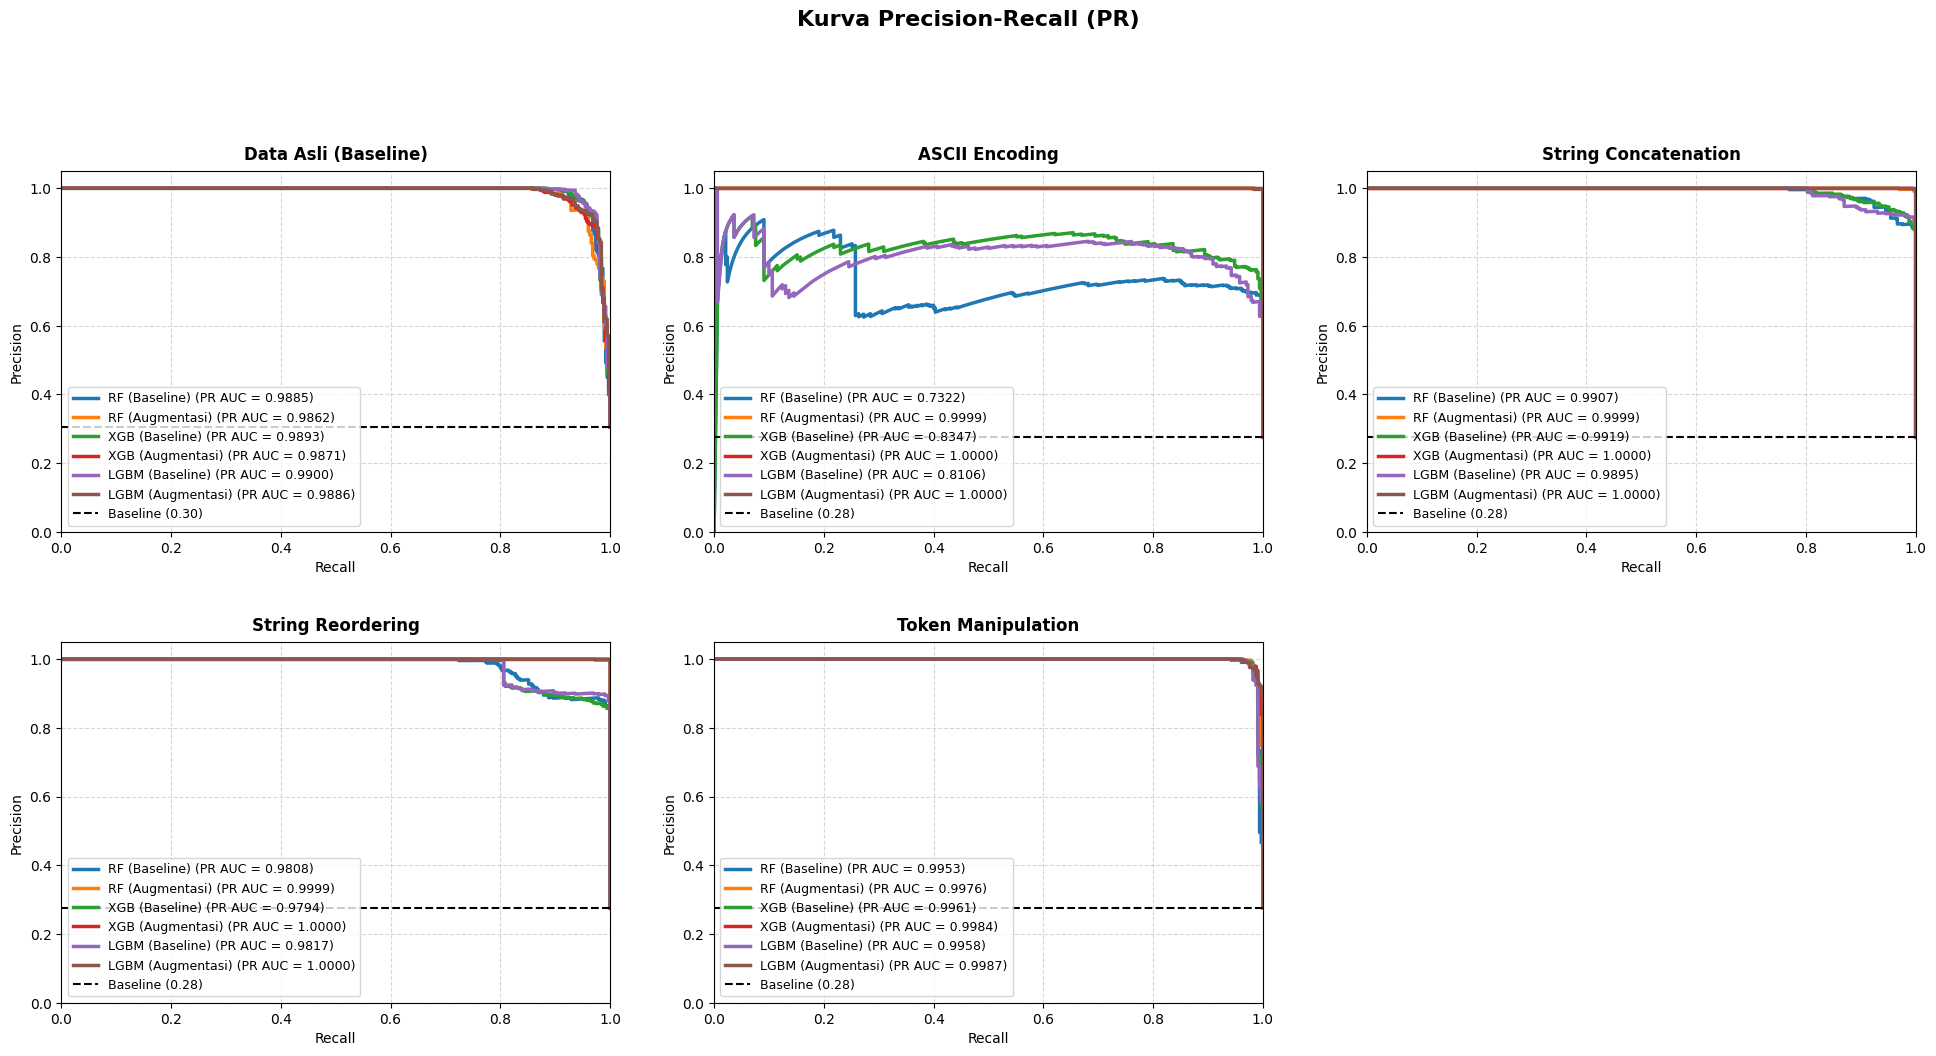

▶ [LANDSCAPE] Grup Visualisasi Kurva PR Berhasil Di-render & Disimpan: pr_curve_all_20260809_110044.png
⏹ EKSEKUSI EVALUASI SELESAI. Total Waktu: 0.38 Menit.


In [8]:
import time
from datetime import datetime

# =====================================================================
# EKSEKUSI PIPA EVALUASI UTAMA DENGAN PENGUKUR WAKTU & KALKULASI FPR/FNR
# =====================================================================
print("="*80)
print(f"▶ MULAI EKSEKUSI PIPELINE EVALUASI: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
waktu_mulai_evaluasi = time.time()

def load_latest_model(model_name: str, skenario: str) -> dict:
    """Mencari dan memuat model .joblib terbaru berdasarkan nama algoritma dan skenario."""
    pattern = str(MODEL_DIR / f"model_{model_name}_{skenario}_*.joblib")
    list_of_files = glob.glob(pattern)
    if not list_of_files:
        return None
    # Menemukan file yang paling akhir dikonstruksi
    latest_file = max(list_of_files, key=os.path.getmtime)
    return joblib.load(latest_file)

print("[*] Memuat seluruh model .joblib terbaru dari direktori output...")
loaded_models = {}
for m_name in ["RandomForest", "XGBoost", "LightGBM"]:
    for sken in ["Baseline", "Augmentasi"]:
        model_payload = load_latest_model(m_name, sken)
        if model_payload is not None:
            # Menyederhanakan singkatan agar grafik terlihat profesional dan rapi
            display_name = m_name.replace("RandomForest", "RF").replace("XGBoost", "XGB").replace("LightGBM", "LGBM")
            key_name = f"{display_name} ({sken})"
            loaded_models[key_name] = model_payload
            print(f"    - Berhasil memuat: {key_name}")

if not loaded_models:
    print("❌ [ERROR] Tidak ada berkas model .joblib ditemukan di folder output/models.")
else:
    print(f"✅ Sukses memuat {len(loaded_models)} arsitektur model untuk dievaluasi.")

    # Membaca dan Mengunci Data Benign Asli dari Skenario Baseline
    base_test_path = INPUT_DIR / BASELINE_TEST_CSV
    if not base_test_path.exists():
        print(f"❌ [ERROR] File induk data uji murni tidak ditemukan di: {base_test_path}")
    else:
        df_base_test = pd.read_csv(base_test_path).fillna(0)
        # Pisahkan komponen Benign murni (label == 0) untuk dicampur ke skenario obfuskasi
        df_benign_clean = df_base_test[df_base_test[LABEL_COL] == 0].copy()

        result_rows = []
        plot_data_registry = {}

        print("\n[*] Menjalankan Pengujian Komparatif Lintas Skenario Teknik...")
        
        for scenario_label, csv_name in TEST_FILES.items():
            csv_path = INPUT_DIR / csv_name
            if not csv_path.exists():
                print(f"[-] Lewati Skenario [{scenario_label}]: Berkas {csv_name} tidak ditemukan.")
                continue
                
            df_scenario_raw = pd.read_csv(csv_path).fillna(0)
            
            # Hubungkan Malicious teknik dengan Benign murni asli
            if scenario_label == "Data Asli (Baseline)":
                df_test_final = df_scenario_raw.copy()
            else:
                df_malicious_obf = df_scenario_raw[df_scenario_raw[LABEL_COL] == 1].copy()
                df_test_final = pd.concat([df_benign_clean, df_malicious_obf]).sample(frac=1, random_state=42).reset_index(drop=True)
            
            models_data = {}
            
            # Iterasi prediksi untuk setiap arsitektur model
            for model_display, payload in loaded_models.items():
                model = payload["model"]
                feature_cols = payload["feature_cols"]
                
                # Penanganan darurat jika terdapat kolom fitur yang tidak konsisten
                for col in feature_cols:
                    if col not in df_test_final.columns:
                        df_test_final[col] = 0
                        
                X_test = df_test_final[feature_cols]
                y_test = df_test_final[LABEL_COL]
                
                # Kalkulasi nilai prediksi kelas dan probabilitas skor
                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
                
                # [DIPERBARUI]: Kalkulasi FPR & FNR dari Confusion Matrix
                cm = confusion_matrix(y_test, y_pred)
                if cm.shape == (2, 2):
                    tn, fp, fn, tp = cm.ravel()
                    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
                    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
                else:
                    fpr, fnr = 0.0, 0.0
                
                # [DIPERBARUI]: Rekam metrik tambahan FPR dan FNR ke dalam database baris
                result_rows.append({
                    "Skenario Uji"  : scenario_label,
                    "Model-Skenario": model_display,
                    "Accuracy"      : accuracy_score(y_test, y_pred),
                    "Precision"     : precision_score(y_test, y_pred, zero_division=0),
                    "Recall"        : recall_score(y_test, y_pred, zero_division=0),
                    "F1-Score"      : f1_score(y_test, y_pred, zero_division=0),
                    "FPR"           : fpr,
                    "FNR"           : fnr,
                    "ROC AUC"       : roc_auc_score(y_test, y_proba),
                    "PR AUC"        : average_precision_score(y_test, y_proba)
                })
                
                models_data[model_display] = {
                    'cm': cm,
                    'y_true': y_test,
                    'y_pred': y_pred,
                    'y_proba': y_proba
                }
                
            plot_data_registry[scenario_label] = models_data

        # 1. Cetak Laporan Output Berbentuk Tabel Teks & CSV Otomatis
        _print_comparison_table_formatted(result_rows, waktu_sekarang)
        
        # 2. Render Diagram Confusion Matrix Berurutan
        print("\n=== VISUALISASI CONFUSION MATRIX INLINE ===")
        for scenario_label, models_data in plot_data_registry.items():
            if models_data:
                _plot_combined_confusion_matrix(scenario_label, models_data, waktu_sekarang)
                
        # 3. Visualisasi Blok Kelompok Kurva ROC (Format Melebar / Landscape)
        print("\n=== MENAMPILKAN BLOK VISUAL 1: GRUP KURVA ROC (LANDSCAPE) ===")
        _plot_roc_curves_landscape_grid(plot_data_registry, waktu_sekarang)
        
        # 4. Visualisasi Blok Kelompok Kurva Precision-Recall (Format Melebar / Landscape)
        print("\n=== MENAMPILKAN BLOK VISUAL 2: GRUP KURVA PRECISION-RECALL (LANDSCAPE) ===")
        _plot_pr_curves_landscape_grid(plot_data_registry, waktu_sekarang)

# Kalkulasi durasi akhir pengujian
durasi_evaluasi = (time.time() - waktu_mulai_evaluasi) / 60
print("="*80)
print(f"⏹ EKSEKUSI EVALUASI SELESAI. Total Waktu: {durasi_evaluasi:.2f} Menit.")
print("="*80)

CELL 4 — RINGKASAN EVALUASI KOMPREHENSIF
Data evaluasi: 30 baris dari evaluasi_test_set_20260809_110044.csv
Model unik    : ['RF', 'XGB', 'LGBM']
Skenario unik : ['Baseline', 'Augmentasi']
Data uji unik : ['Data Asli (Baseline)', 'ASCII Encoding', 'String Concatenation', 'String Reordering', 'Token Manipulation']

                          1. TABEL RATA-RATA EVALUASI PER MODEL                           
                    (rata-rata metrik di seluruh 5 skenario data uji)                     

Model-Skenario               Accuracy   Precision      Recall    F1-Score         FPR         FNR     ROC AUC
-------------------------------------------------------------------------------------------------------------
LGBM (Augmentasi)              0.9815      0.9515      0.9854      0.9680      0.0197      0.0146      0.9985
XGB (Augmentasi)               0.9805      0.9488      0.9849      0.9663      0.0209      0.0151      0.9982
RF (Augmentasi)                0.9785      0.9434      0.9839

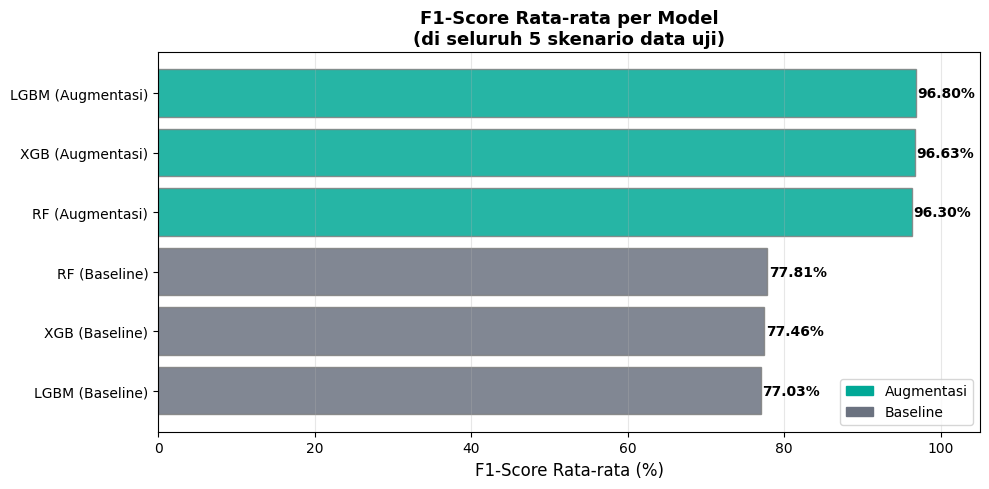

Grafik tersimpan: f1_rata_rata_per_model_20260809_110044.png


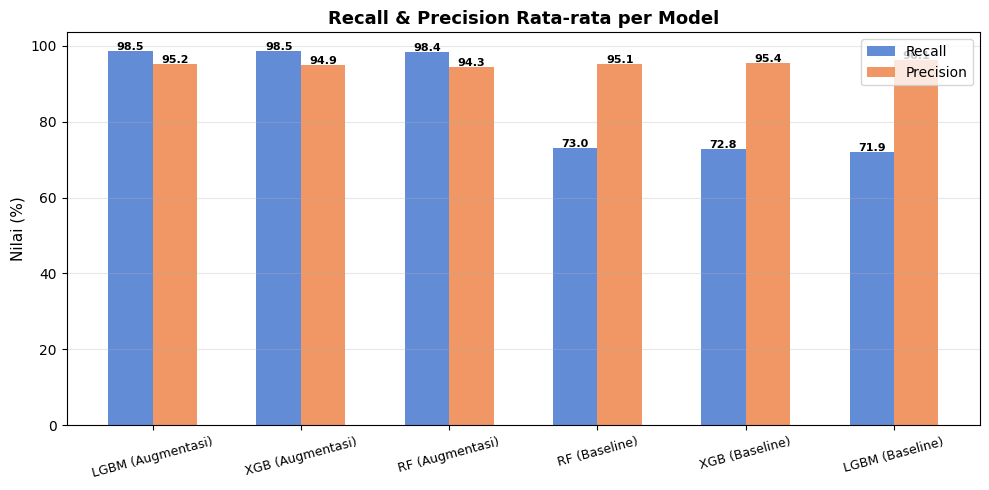

Grafik tersimpan: recall_precision_per_model_20260809_110044.png

                         2. TABEL RATA-RATA EVALUASI PER DATA UJI                         
                          (rata-rata metrik di seluruh 6 model)                           

Skenario Uji                      Accuracy   Precision      Recall    F1-Score         FPR         FNR     ROC AUC
------------------------------------------------------------------------------------------------------------------
Data Asli (Baseline)                0.9696      0.9682      0.9310      0.9491      0.0136      0.0690      0.9923
ASCII Encoding                      0.8627      0.8943      0.5399      0.5593      0.0136      0.4601      0.9724
String Concatenation                0.9677      0.9648      0.9187      0.9384      0.0136      0.0813      0.9982
String Reordering                   0.9631      0.9644      0.9020      0.9285      0.0136      0.0980      0.9962
Token Manipulation                  0.9859      0.9658      0

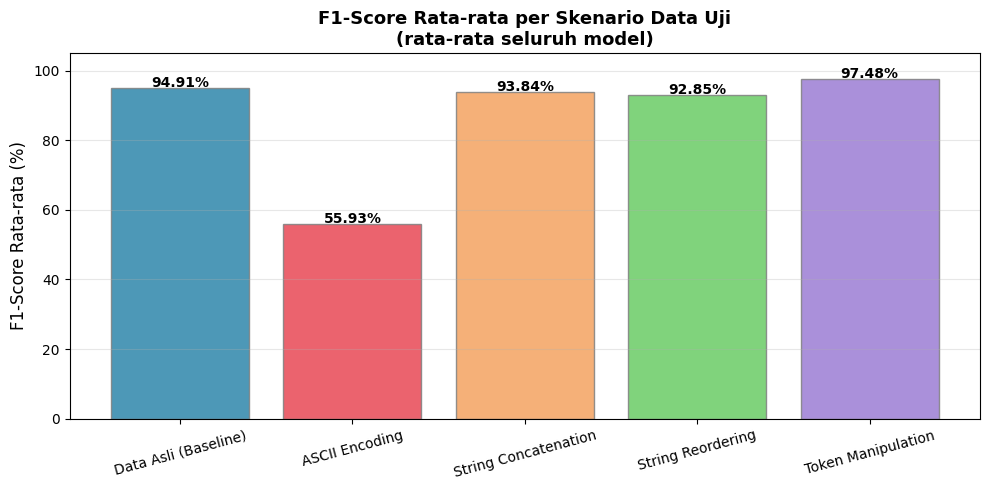

Grafik tersimpan: f1_rata_rata_per_data_uji_20260809_110044.png


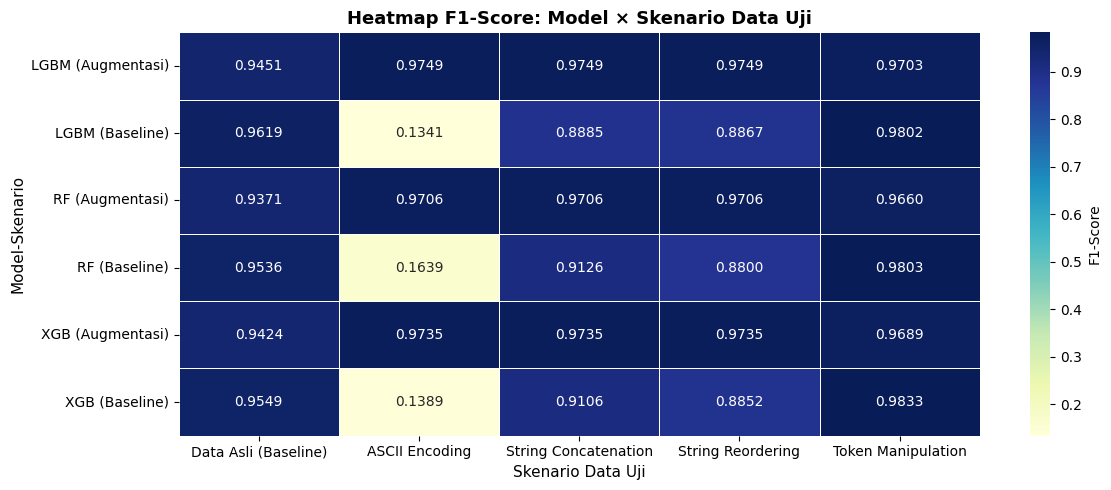

Grafik tersimpan: heatmap_f1_20260809_110044.png

                      3. TABEL CONFUSION MATRIX PER SKENARIO × MODEL                      

  [Data Asli (Baseline)]
  Model                         TN     FP     FN     TP   Recall     Prec       F1
  ---------------------------------------------------------------------------
  RF (Baseline)                855      6     28    349   0.9257   0.9831   0.9536
  RF (Augmentasi)              841     20     27    350   0.9284   0.9459   0.9371
  XGB (Baseline)               856      5     28    349   0.9257   0.9859   0.9549
  XGB (Augmentasi)             843     18     25    352   0.9337   0.9514   0.9424
  LGBM (Baseline)              857      4     24    353   0.9363   0.9888   0.9619
  LGBM (Augmentasi)            844     17     24    353   0.9363   0.9541   0.9451

  [ASCII Encoding]
  Model                         TN     FP     FN     TP   Recall     Prec       F1
  ---------------------------------------------------------------------

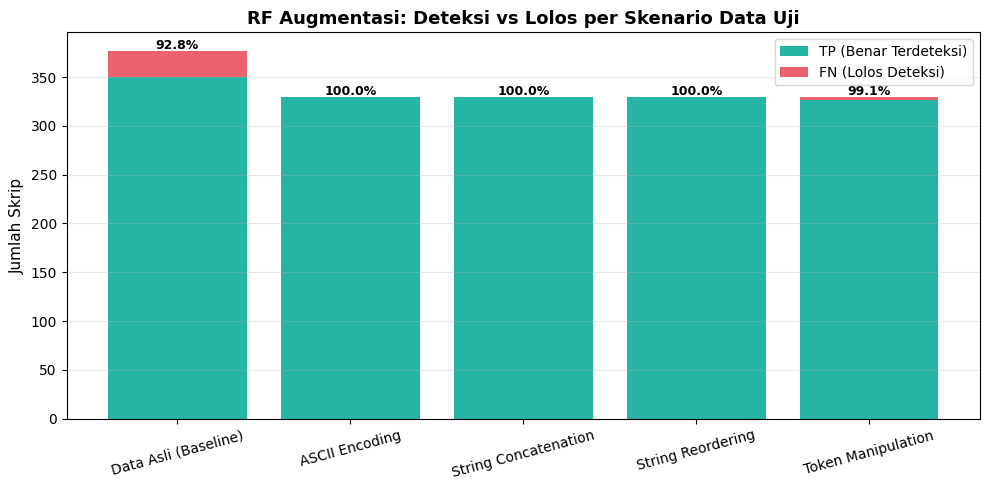

Grafik tersimpan: tp_fn_stacked_20260809_110044.png

✅ CELL 4 — Ringkasan evaluasi selesai.


In [9]:
# =====================================================================
# CELL 4 — RINGKASAN EVALUASI: TABEL RATA-RATA + GRAFIK BATANG + CM
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

print("=" * 80)
print("CELL 4 — RINGKASAN EVALUASI KOMPREHENSIF")
print("=" * 80)

# Baca CSV hasil evaluasi yang sudah tersimpan dari Cell 3
csv_eval = sorted(METRIC_OUT_DIR.glob("evaluasi_test_set_*.csv"))
if not csv_eval:
    raise FileNotFoundError("Jalankan Cell 3 terlebih dahulu.")
df_all = pd.read_csv(csv_eval[-1])  # file terbaru

# Pastikan kolom numerik
FLOAT_COLS = ["Accuracy","Precision","Recall","F1-Score","FPR","FNR","ROC AUC","PR AUC"]
for c in FLOAT_COLS:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# Pisahkan nama model dan skenario
df_all["Model"]    = df_all["Model-Skenario"].str.extract(r"^(\w+)")
df_all["Skenario"] = df_all["Model-Skenario"].str.extract(r"\((\w+)\)")

print(f"Data evaluasi: {len(df_all)} baris dari {csv_eval[-1].name}")
print(f"Model unik    : {df_all['Model'].unique().tolist()}")
print(f"Skenario unik : {df_all['Skenario'].unique().tolist()}")
print(f"Data uji unik : {df_all['Skenario Uji'].unique().tolist()}")

# =====================================================================
# 1. TABEL RATA-RATA EVALUASI PER MODEL (rata-rata seluruh data uji)
# =====================================================================
print(f"\n{'='*90}")
print(f"{'1. TABEL RATA-RATA EVALUASI PER MODEL':^90}")
print(f"{'(rata-rata metrik di seluruh 5 skenario data uji)':^90}")
print(f"{'='*90}")

METRIK = ["Accuracy","Precision","Recall","F1-Score","FPR","FNR","ROC AUC"]
df_per_model = df_all.groupby("Model-Skenario")[METRIK].mean().reset_index()
df_per_model = df_per_model.sort_values("F1-Score", ascending=False)

print(f"\n{'Model-Skenario':<25}", end="")
for m in METRIK:
    print(f"{m:>12}", end="")
print()
print("-" * (25 + 12*len(METRIK)))
for _, r in df_per_model.iterrows():
    print(f"{r['Model-Skenario']:<25}", end="")
    for m in METRIK:
        print(f"{r[m]:>12.4f}", end="")
    print()
print("=" * (25 + 12*len(METRIK)))

# Simpan CSV
csv_per_model = METRIC_OUT_DIR / f"rata_rata_per_model_{waktu_sekarang}.csv"
df_per_model.to_csv(csv_per_model, index=False)
print(f"Tersimpan: {csv_per_model.name}")

# ── Grafik 1: F1-Score rata-rata per model ────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 5))
models_sorted = df_per_model.sort_values("F1-Score")
colors1 = ["#00A896" if "Augmentasi" in n else "#6B7280"
           for n in models_sorted["Model-Skenario"]]
bars1 = ax1.barh(models_sorted["Model-Skenario"],
                 models_sorted["F1-Score"] * 100,
                 color=colors1, alpha=0.85, edgecolor="gray")
for bar, val in zip(bars1, models_sorted["F1-Score"] * 100):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}%", va="center", fontsize=10, fontweight="bold")
ax1.set_xlabel("F1-Score Rata-rata (%)", fontsize=12)
ax1.set_title("F1-Score Rata-rata per Model\n(di seluruh 5 skenario data uji)",
              fontsize=13, fontweight="bold")
ax1.set_xlim(0, 105)
ax1.grid(axis="x", alpha=0.3)
patches1 = [mpatches.Patch(color="#00A896", label="Augmentasi"),
            mpatches.Patch(color="#6B7280", label="Baseline")]
ax1.legend(handles=patches1, fontsize=10)
plt.tight_layout()
f1_path = GRAPH_OUT_DIR / f"f1_rata_rata_per_model_{waktu_sekarang}.png"
plt.savefig(f1_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Grafik tersimpan: {f1_path.name}")

# ── Grafik 2: Grouped bar Recall + Precision per model ────────────────
fig1b, ax1b = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_per_model))
w = 0.3
recall_vals    = df_per_model["Recall"].values * 100
precision_vals = df_per_model["Precision"].values * 100
bars_r = ax1b.bar(x - w/2, recall_vals, w, label="Recall", color="#4878D0", alpha=0.85)
bars_p = ax1b.bar(x + w/2, precision_vals, w, label="Precision", color="#EE854A", alpha=0.85)
for bar in list(bars_r) + list(bars_p):
    ax1b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
              f"{bar.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
ax1b.set_xticks(x)
ax1b.set_xticklabels(df_per_model["Model-Skenario"], fontsize=9, rotation=15)
ax1b.set_ylabel("Nilai (%)", fontsize=11)
ax1b.set_title("Recall & Precision Rata-rata per Model", fontsize=13, fontweight="bold")
ax1b.legend(fontsize=10)
ax1b.grid(axis="y", alpha=0.3)
plt.tight_layout()
rp_path = GRAPH_OUT_DIR / f"recall_precision_per_model_{waktu_sekarang}.png"
plt.savefig(rp_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Grafik tersimpan: {rp_path.name}")

# =====================================================================
# 2. TABEL RATA-RATA EVALUASI PER DATA UJI (rata-rata seluruh model)
# =====================================================================
print(f"\n{'='*90}")
print(f"{'2. TABEL RATA-RATA EVALUASI PER DATA UJI':^90}")
print(f"{'(rata-rata metrik di seluruh 6 model)':^90}")
print(f"{'='*90}")

df_per_uji = df_all.groupby("Skenario Uji")[METRIK].mean().reset_index()
# Urutkan sesuai urutan logis
urutan = ["Data Asli (Baseline)","ASCII Encoding","String Concatenation",
          "String Reordering","Token Manipulation"]
df_per_uji["sort_key"] = df_per_uji["Skenario Uji"].map(
    {v:i for i,v in enumerate(urutan)})
df_per_uji = df_per_uji.sort_values("sort_key").drop("sort_key", axis=1)

print(f"\n{'Skenario Uji':<30}", end="")
for m in METRIK:
    print(f"{m:>12}", end="")
print()
print("-" * (30 + 12*len(METRIK)))
for _, r in df_per_uji.iterrows():
    print(f"{r['Skenario Uji']:<30}", end="")
    for m in METRIK:
        print(f"{r[m]:>12.4f}", end="")
    print()
print("=" * (30 + 12*len(METRIK)))

csv_per_uji = METRIC_OUT_DIR / f"rata_rata_per_data_uji_{waktu_sekarang}.csv"
df_per_uji.to_csv(csv_per_uji, index=False)
print(f"Tersimpan: {csv_per_uji.name}")

# ── Grafik 3: F1-Score per data uji ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 5))
colors2 = ["#2E86AB","#E84855","#F4A261","#6ACC65","#9B7DD4"]
bars2 = ax2.bar(df_per_uji["Skenario Uji"], df_per_uji["F1-Score"]*100,
                color=colors2[:len(df_per_uji)], alpha=0.85, edgecolor="gray")
for bar, val in zip(bars2, df_per_uji["F1-Score"]*100):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"{val:.2f}%", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylabel("F1-Score Rata-rata (%)", fontsize=12)
ax2.set_title("F1-Score Rata-rata per Skenario Data Uji\n(rata-rata seluruh model)",
              fontsize=13, fontweight="bold")
ax2.set_ylim(0, 105)
ax2.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15, fontsize=10)
plt.tight_layout()
f2_path = GRAPH_OUT_DIR / f"f1_rata_rata_per_data_uji_{waktu_sekarang}.png"
plt.savefig(f2_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Grafik tersimpan: {f2_path.name}")

# ── Grafik 4: Heatmap F1 model × data uji ────────────────────────────
pivot = df_all.pivot_table(values="F1-Score", index="Model-Skenario",
                           columns="Skenario Uji", aggfunc="mean")
# Urutkan kolom
pivot = pivot[[c for c in urutan if c in pivot.columns]]

fig3, ax3 = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax3,
            linewidths=0.5, cbar_kws={"label": "F1-Score"})
ax3.set_title("Heatmap F1-Score: Model × Skenario Data Uji", fontsize=13, fontweight="bold")
ax3.set_ylabel("Model-Skenario", fontsize=11)
ax3.set_xlabel("Skenario Data Uji", fontsize=11)
plt.tight_layout()
f3_path = GRAPH_OUT_DIR / f"heatmap_f1_{waktu_sekarang}.png"
plt.savefig(f3_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Grafik tersimpan: {f3_path.name}")

# =====================================================================
# 3. CONFUSION MATRIX DETAIL PER SKENARIO × MODEL
# =====================================================================
print(f"\n{'='*90}")
print(f"{'3. TABEL CONFUSION MATRIX PER SKENARIO × MODEL':^90}")
print(f"{'='*90}")

# Recompute CM dari data yang masih ada di memory (plot_data_registry)
if 'plot_data_registry' in dir() or 'plot_data_registry' in globals():
    cm_records = []

    for scenario_label, models_data in plot_data_registry.items():
        print(f"\n  [{scenario_label}]")
        print(f"  {'Model':<25} {'TN':>6} {'FP':>6} {'FN':>6} {'TP':>6} {'Recall':>8} {'Prec':>8} {'F1':>8}")
        print(f"  {'-'*75}")

        for model_name, m_data in models_data.items():
            cm = m_data['cm']
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
            else:
                tn, fp, fn, tp = 0, 0, 0, 0

            recall = tp/(tp+fn) if (tp+fn) > 0 else 0
            prec   = tp/(tp+fp) if (tp+fp) > 0 else 0
            f1     = 2*prec*recall/(prec+recall) if (prec+recall) > 0 else 0

            print(f"  {model_name:<25} {tn:>6} {fp:>6} {fn:>6} {tp:>6} {recall:>8.4f} {prec:>8.4f} {f1:>8.4f}")

            cm_records.append({
                "Skenario Uji": scenario_label,
                "Model": model_name,
                "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                "Recall": round(recall, 4),
                "Precision": round(prec, 4),
                "F1-Score": round(f1, 4),
            })

    df_cm = pd.DataFrame(cm_records)
    cm_csv = METRIC_OUT_DIR / f"confusion_matrix_detail_{waktu_sekarang}.csv"
    df_cm.to_csv(cm_csv, index=False)
    print(f"\n✅ Confusion matrix detail tersimpan: {cm_csv.name}")

    # ── Grafik 5: Stacked bar TP/FN per skenario (model terbaik) ──────
    # Filter hanya model Augmentasi
    df_cm_aug = df_cm[df_cm["Model"].str.contains("Augmentasi")]

    if len(df_cm_aug) > 0:
        # Ambil RF Augmentasi saja untuk clarity
        df_cm_rf = df_cm_aug[df_cm_aug["Model"].str.contains("RF")]
        if len(df_cm_rf) > 0:
            fig5, ax5 = plt.subplots(figsize=(10, 5))
            skenario_labels = df_cm_rf["Skenario Uji"].tolist()
            tp_vals = df_cm_rf["TP"].values
            fn_vals = df_cm_rf["FN"].values

            x5 = np.arange(len(skenario_labels))
            ax5.bar(x5, tp_vals, label="TP (Benar Terdeteksi)", color="#00A896", alpha=0.85)
            ax5.bar(x5, fn_vals, bottom=tp_vals, label="FN (Lolos Deteksi)", color="#E84855", alpha=0.85)

            for j in range(len(x5)):
                total = tp_vals[j] + fn_vals[j]
                if total > 0:
                    pct = tp_vals[j]/total*100
                    ax5.text(x5[j], total + 2, f"{pct:.1f}%", ha="center", fontsize=9, fontweight="bold")

            ax5.set_xticks(x5)
            ax5.set_xticklabels(skenario_labels, fontsize=10, rotation=15)
            ax5.set_ylabel("Jumlah Skrip", fontsize=11)
            ax5.set_title("RF Augmentasi: Deteksi vs Lolos per Skenario Data Uji",
                          fontsize=13, fontweight="bold")
            ax5.legend(fontsize=10)
            ax5.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            f5_path = GRAPH_OUT_DIR / f"tp_fn_stacked_{waktu_sekarang}.png"
            plt.savefig(f5_path, dpi=300, bbox_inches="tight")
            plt.show()
            print(f"Grafik tersimpan: {f5_path.name}")

else:
    print("  [INFO] plot_data_registry tidak tersedia — jalankan Cell 3 terlebih dahulu.")

print(f"\n✅ CELL 4 — Ringkasan evaluasi selesai.")


CELL 5 — GRAFIK BATANG METRIK PENENTU MODEL TERBAIK
Terbaik Augmentasi : LGBM (Augmentasi)  (F1=0.9680)
Terbaik Baseline   : RF (Baseline) (F1=0.7781)


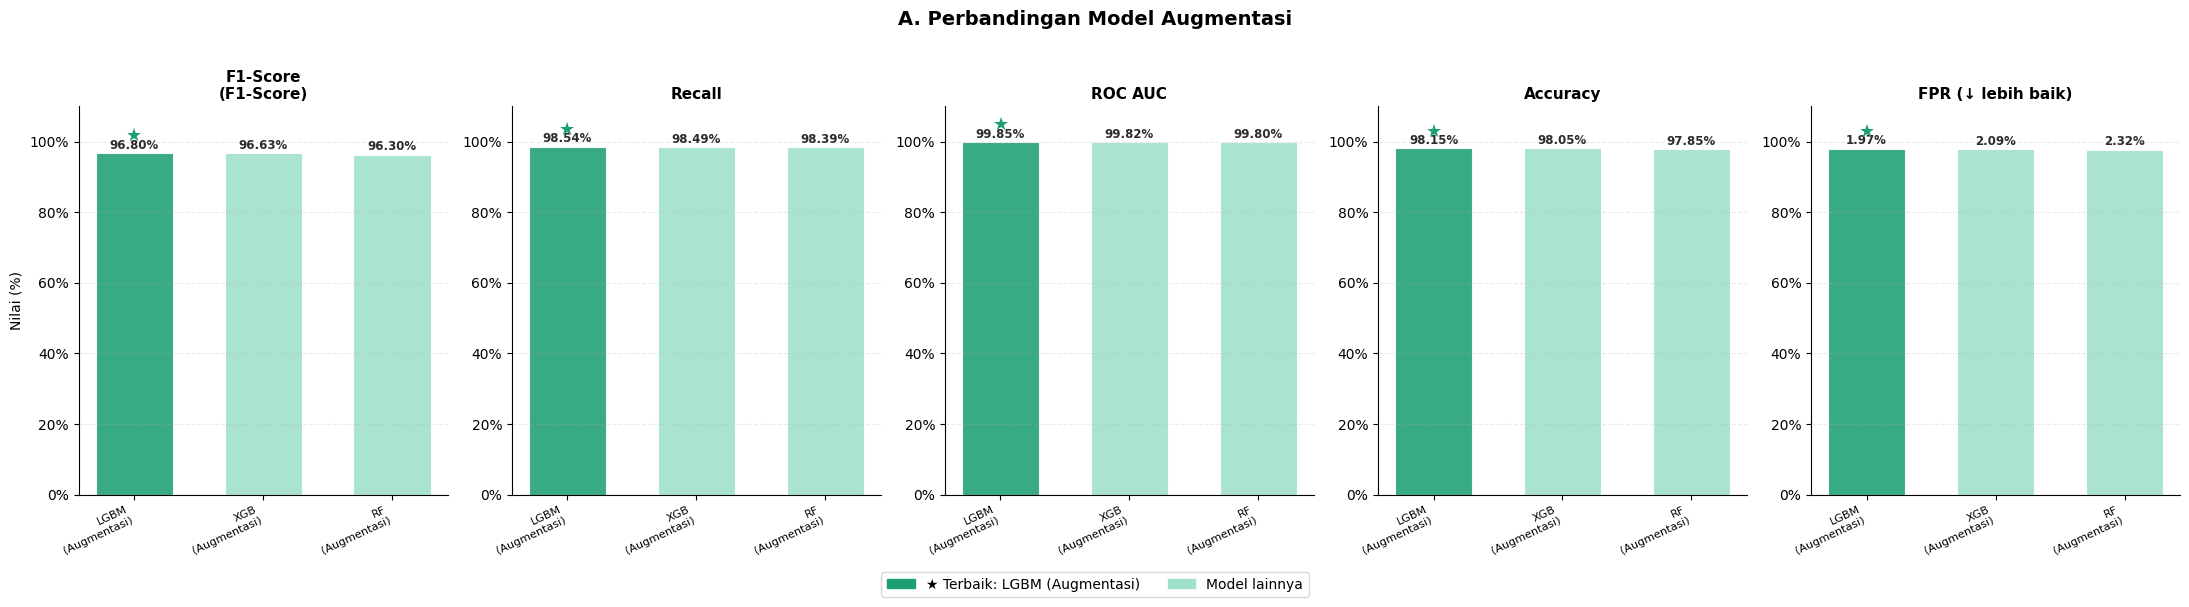


✅ Grafik A tersimpan: metrik_augmentasi_20260809_110044.png


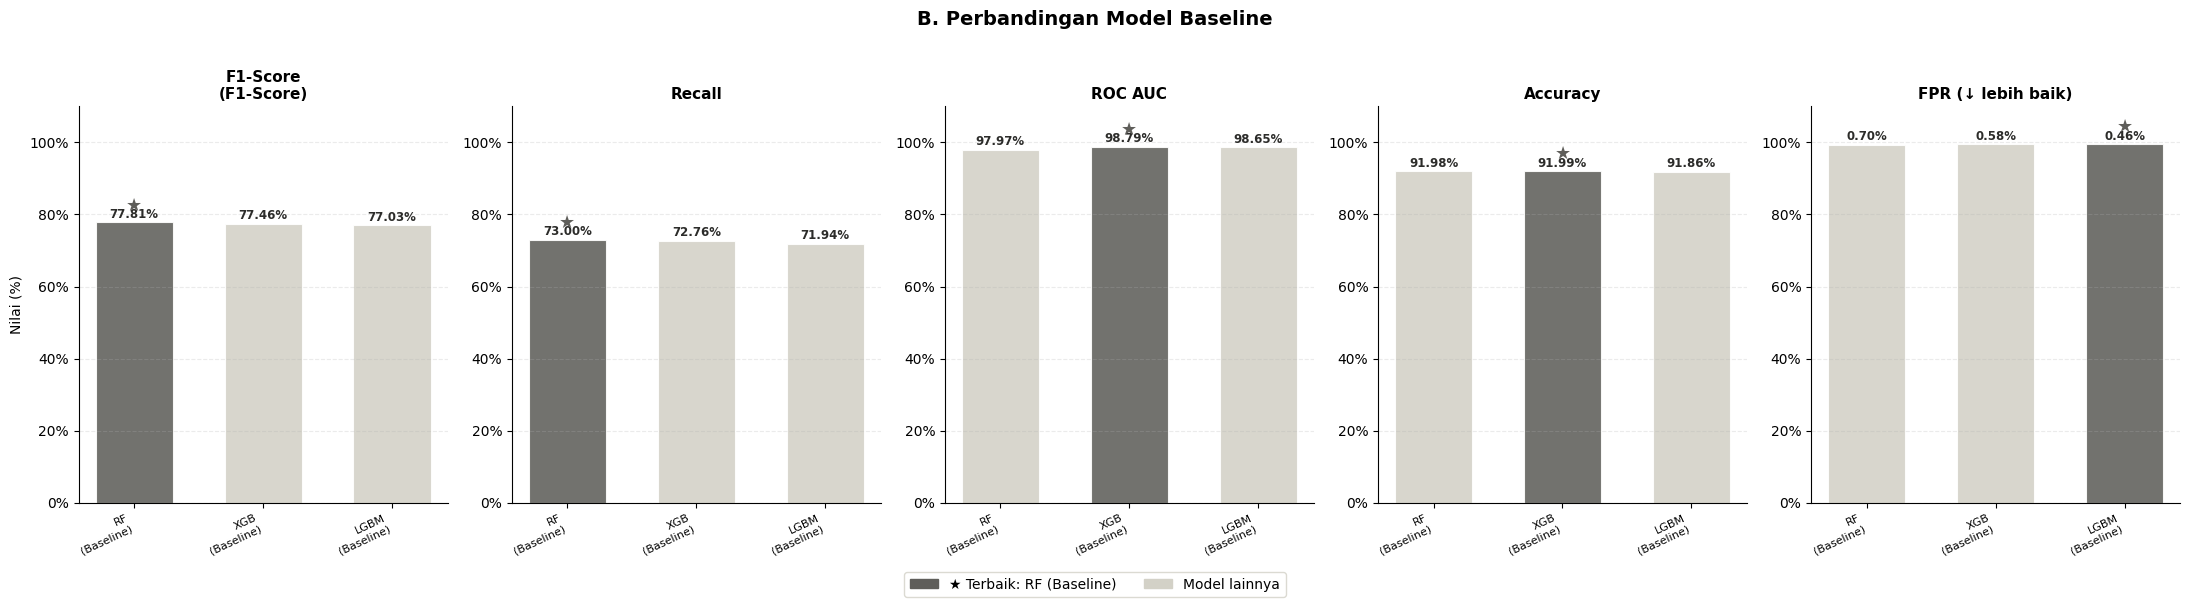


✅ Grafik B tersimpan: metrik_baseline_20260809_110044.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18064\2200100082.py:183: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



✅ Grafik C tersimpan: head_to_head_20260809_110044.png

KESIMPULAN PENENTUAN MODEL TERBAIK
  Terbaik Augmentasi : LGBM (Augmentasi)
    F1-Score            : 0.9680
    Recall              : 0.9854
    ROC AUC             : 0.9985
    Accuracy            : 0.9815
    FPR (↓ lebih baik)  : 0.0197

  Terbaik Baseline   : RF (Baseline)
    F1-Score            : 0.7781
    Recall              : 0.7300
    ROC AUC             : 0.9797
    Accuracy            : 0.9198
    FPR (↓ lebih baik)  : 0.0070

✅ CELL 5 selesai. 3 grafik tersimpan di: output\grafik


In [10]:
# =====================================================================
# CELL 5 — GRAFIK BATANG SEMUA METRIK PENENTU MODEL TERBAIK
#
# Struktur 3 grafik:
#   A. Perbandingan model Augmentasi saja
#   B. Perbandingan model Baseline saja
#   C. Head-to-head: terbaik Augmentasi vs terbaik Baseline
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print("=" * 80)
print("CELL 5 — GRAFIK BATANG METRIK PENENTU MODEL TERBAIK")
print("=" * 80)

# ── Baca data ─────────────────────────────────────────────────────────
csv_eval = sorted(METRIC_OUT_DIR.glob("evaluasi_test_set_*.csv"))
if not csv_eval:
    raise FileNotFoundError("Jalankan Cell 3 terlebih dahulu.")

df_all = pd.read_csv(csv_eval[-1])
FLOAT_COLS = ["Accuracy", "Precision", "Recall", "F1-Score", "FPR", "FNR", "ROC AUC"]
for c in FLOAT_COLS:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

df_avg = df_all.groupby("Model-Skenario")[FLOAT_COLS].mean().reset_index()

# Pisahkan kelompok
df_aug  = df_avg[df_avg["Model-Skenario"].str.contains("Augmentasi")].sort_values("F1-Score", ascending=False).reset_index(drop=True)
df_base = df_avg[df_avg["Model-Skenario"].str.contains("Baseline")].sort_values("F1-Score", ascending=False).reset_index(drop=True)

# Model terbaik tiap kelompok
best_aug  = df_aug.iloc[0]
best_base = df_base.iloc[0]

print(f"Terbaik Augmentasi : {best_aug['Model-Skenario']}  (F1={best_aug['F1-Score']:.4f})")
print(f"Terbaik Baseline   : {best_base['Model-Skenario']} (F1={best_base['F1-Score']:.4f})")

METRIK_PANEL = [
    ("F1-Score", "F1-Score",       False),
    ("Recall",   "Recall",         False),
    ("ROC AUC",  "ROC AUC",        False),
    ("Accuracy", "Accuracy",       False),
    ("FPR",      "FPR (↓ lebih baik)", True),
]

def plot_group(df_group, title, bar_color, star_color, ax_row, fig):
    """Plot 5 panel metrik untuk satu kelompok model."""
    models = df_group["Model-Skenario"].tolist()
    x = np.arange(len(models))

    for col_idx, (col, label, invert) in enumerate(METRIK_PANEL):
        ax = ax_row[col_idx]
        vals_pct = df_group[col].values * 100

        if invert:
            disp = (1 - df_group[col].values) * 100
        else:
            disp = vals_pct

        best_idx = int(np.argmax(disp))
        bar_colors = [star_color if i == best_idx else bar_color
                      for i in range(len(models))]

        bars = ax.bar(x, disp, color=bar_colors, alpha=0.88,
                      edgecolor="white", linewidth=0.8, width=0.6)

        for i, (bar, orig) in enumerate(zip(bars, vals_pct)):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f"{orig:.2f}%",
                ha="center", va="bottom",
                fontsize=8.5, fontweight="bold", color="#2C2C2A"
            )

        # Bintang di model terbaik
        ax.text(x[best_idx], disp[best_idx] + 2.2, "★",
                ha="center", va="bottom", fontsize=13, color=star_color)

        short_labels = [m.replace(" (", "\n(") for m in models]
        ax.set_title(label, fontsize=11, fontweight="bold", pad=5)
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, fontsize=8, rotation=25, ha="right")
        ax.set_ylim(0, 110)
        ax.set_ylabel("Nilai (%)" if col_idx == 0 else "", fontsize=10)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

    # Judul baris
    ax_row[0].set_title(f"F1-Score\n({title})", fontsize=11, fontweight="bold", pad=5)

# ── GRAFIK A — Augmentasi ─────────────────────────────────────────────
fig_a, axes_a = plt.subplots(1, 5, figsize=(22, 5.5))
fig_a.suptitle("A. Perbandingan Model Augmentasi", fontsize=14,
               fontweight="bold", y=1.02)
plot_group(df_aug, "F1-Score", "#9FE1CB", "#1D9E75", axes_a, fig_a)

leg_a = [mpatches.Patch(color="#1D9E75", label=f"★ Terbaik: {best_aug['Model-Skenario']}"),
         mpatches.Patch(color="#9FE1CB", label="Model lainnya")]
fig_a.legend(handles=leg_a, loc="lower center", ncol=2, fontsize=10,
             bbox_to_anchor=(0.5, -0.06), frameon=True, edgecolor="#D3D1C7")
plt.tight_layout()
path_a = GRAPH_OUT_DIR / f"metrik_augmentasi_{waktu_sekarang}.png"
plt.savefig(path_a, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n✅ Grafik A tersimpan: {path_a.name}")

# ── GRAFIK B — Baseline ───────────────────────────────────────────────
fig_b, axes_b = plt.subplots(1, 5, figsize=(22, 5.5))
fig_b.suptitle("B. Perbandingan Model Baseline", fontsize=14,
               fontweight="bold", y=1.02)
plot_group(df_base, "F1-Score", "#D3D1C7", "#5F5E5A", axes_b, fig_b)

leg_b = [mpatches.Patch(color="#5F5E5A", label=f"★ Terbaik: {best_base['Model-Skenario']}"),
         mpatches.Patch(color="#D3D1C7", label="Model lainnya")]
fig_b.legend(handles=leg_b, loc="lower center", ncol=2, fontsize=10,
             bbox_to_anchor=(0.5, -0.06), frameon=True, edgecolor="#D3D1C7")
plt.tight_layout()
path_b = GRAPH_OUT_DIR / f"metrik_baseline_{waktu_sekarang}.png"
plt.savefig(path_b, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n✅ Grafik B tersimpan: {path_b.name}")

# ── GRAFIK C — Head-to-Head ───────────────────────────────────────────
df_h2h = pd.DataFrame([best_aug, best_base]).reset_index(drop=True)
labels_h2h = df_h2h["Model-Skenario"].tolist()
x_h2h = np.arange(len(labels_h2h))
COLORS_H2H = ["#1D9E75", "#5F5E5A"]

fig_c, axes_c = plt.subplots(1, 5, figsize=(18, 5.5))
fig_c.suptitle(
    f"C. Head-to-Head: Terbaik Augmentasi vs Terbaik Baseline\n"
    f"{labels_h2h[0]}  vs  {labels_h2h[1]}",
    fontsize=13, fontweight="bold", y=1.04
)

for col_idx, (col, label, invert) in enumerate(METRIK_PANEL):
    ax = axes_c[col_idx]
    vals_pct = df_h2h[col].values * 100
    disp = (1 - df_h2h[col].values) * 100 if invert else vals_pct
    winner_idx = int(np.argmax(disp))

    bars = ax.bar(x_h2h, disp, color=COLORS_H2H, alpha=0.88,
                  edgecolor="white", linewidth=0.8, width=0.5)

    for i, (bar, orig) in enumerate(zip(bars, vals_pct)):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f"{orig:.4f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#2C2C2A"
        )

    # Anotasi selisih
    delta = abs(disp[0] - disp[1])
    ax.text(0.5, 102, f"Δ = {delta:.2f}%",
            ha="center", va="bottom", fontsize=9,
            color="#D85A30", fontweight="bold",
            transform=ax.get_xaxis_transform())

    ax.set_title(label, fontsize=11, fontweight="bold", pad=5)
    ax.set_xticks(x_h2h)
    ax.set_xticklabels([m.replace(" (", "\n(") for m in labels_h2h],
                       fontsize=9, rotation=20, ha="right")
    ax.set_ylim(0, 110)
    ax.set_ylabel("Nilai (%)" if col_idx == 0 else "", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

leg_c = [mpatches.Patch(color="#1D9E75", label=f"Terbaik Augmentasi: {labels_h2h[0]}"),
         mpatches.Patch(color="#5F5E5A", label=f"Terbaik Baseline: {labels_h2h[1]}"),
         mpatches.Patch(color="#D85A30", label="Δ = selisih antar model", alpha=0)]
fig_c.legend(handles=leg_c, loc="lower center", ncol=3, fontsize=10,
             bbox_to_anchor=(0.5, -0.08), frameon=True, edgecolor="#D3D1C7")
plt.tight_layout()
path_c = GRAPH_OUT_DIR / f"head_to_head_{waktu_sekarang}.png"
plt.savefig(path_c, dpi=300, bbox_inches="tight")
plt.show()
print(f"\n✅ Grafik C tersimpan: {path_c.name}")

# ── Ringkasan teks ────────────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"KESIMPULAN PENENTUAN MODEL TERBAIK")
print(f"{'='*80}")
print(f"  Terbaik Augmentasi : {best_aug['Model-Skenario']}")
for col, label, _ in METRIK_PANEL:
    print(f"    {label:<20}: {best_aug[col]:.4f}")
print()
print(f"  Terbaik Baseline   : {best_base['Model-Skenario']}")
for col, label, _ in METRIK_PANEL:
    print(f"    {label:<20}: {best_base[col]:.4f}")
print(f"{'='*80}")
print(f"\n✅ CELL 5 selesai. 3 grafik tersimpan di: {GRAPH_OUT_DIR}")
